In [20]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost imbalanced-learn optuna streamlit shap

In [22]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


from sklearn.pipeline import Pipeline

print('All libraries imported successfully!')

All libraries imported successfully!


In [24]:
df = pd.read_csv('70000rowdataset.csv', sep=';')


print(df.head())
print('Dataset Shape:', df.shape)
print(df.columns)
print(df.info())
df.describe()
print(df.isnull().sum())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
Dataset Shape: (70000, 13)
Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ---------

In [26]:
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


## **DATA CLEANING**

In [28]:
print('Duplicates BEFORE:', df.duplicated().sum())



df = df.drop_duplicates()


print('Duplicates AFTER:', df.duplicated().sum())


print('New Shape:', df.shape)

Duplicates BEFORE: 0
Duplicates AFTER: 0
New Shape: (70000, 13)


In [32]:
df['age_years'] = (df['age'] / 365).astype(int)


print(df[['age', 'age_years']].head())

     age  age_years
0  18393         50
1  20228         55
2  18857         51
3  17623         48
4  17474         47


In [34]:
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
print(df[['height', 'weight', 'BMI']].head())

   height  weight        BMI
0     168    62.0  21.967120
1     156    85.0  34.927679
2     165    64.0  23.507805
3     169    82.0  28.710479
4     156    56.0  23.011177


In [36]:
print('Minimum Height:', df['height'].min())
print('Maximum Height:', df['height'].max())

print('Minimum Weight:', df['weight'].min())
print('Maximum Weight:', df['weight'].max())

print('Minimum ap_hi:', df['ap_hi'].min())
print('Maximum ap_hi:', df['ap_hi'].max())

print('Minimum ap_lo:', df['ap_lo'].min())
print('Maximum ap_lo:', df['ap_lo'].max())

Minimum Height: 55
Maximum Height: 250
Minimum Weight: 10.0
Maximum Weight: 200.0
Minimum ap_hi: -150
Maximum ap_hi: 16020
Minimum ap_lo: -70
Maximum ap_lo: 11000


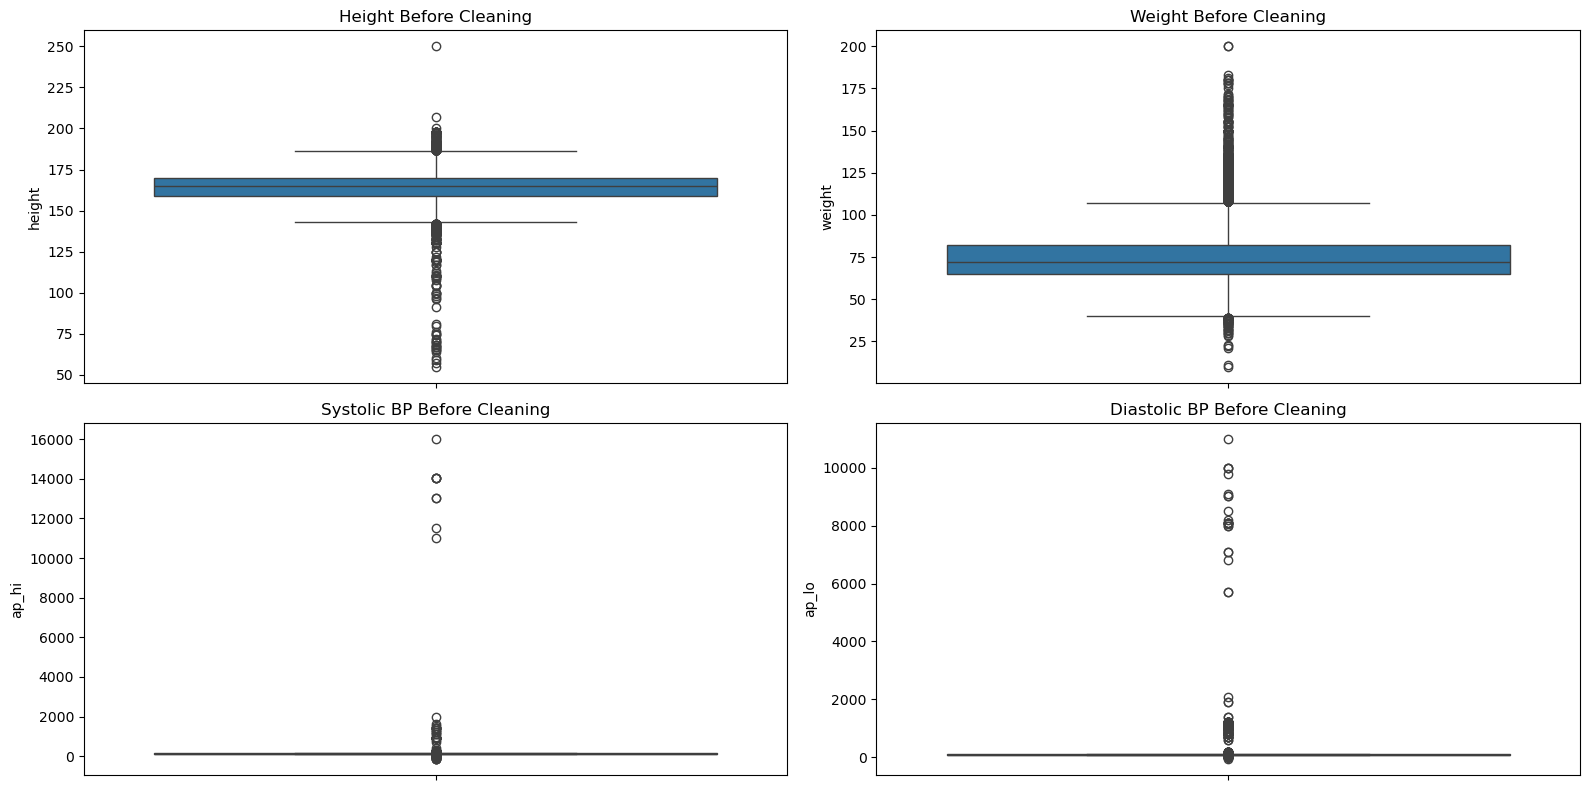

In [38]:
plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.boxplot(df['height'])
plt.title('Height Before Cleaning')

plt.subplot(2,2,2)
sns.boxplot(df['weight'])
plt.title('Weight Before Cleaning')

plt.subplot(2,2,3)
sns.boxplot(df['ap_hi'])
plt.title('Systolic BP Before Cleaning')

plt.subplot(2,2,4)
sns.boxplot(df['ap_lo'])
plt.title('Diastolic BP Before Cleaning')

plt.tight_layout()
plt.show()

In [40]:
df = df[(df['height'] >= 120) & (df['height'] <= 220)]

df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print('Shape after height/weight cleaning:', df.shape)

Shape after height/weight cleaning: (69940, 15)


In [42]:
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]

df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 160)]

df = df[df['ap_hi'] > df['ap_lo']]

print('Shape after BP cleaning:', df.shape)

Shape after BP cleaning: (68608, 15)


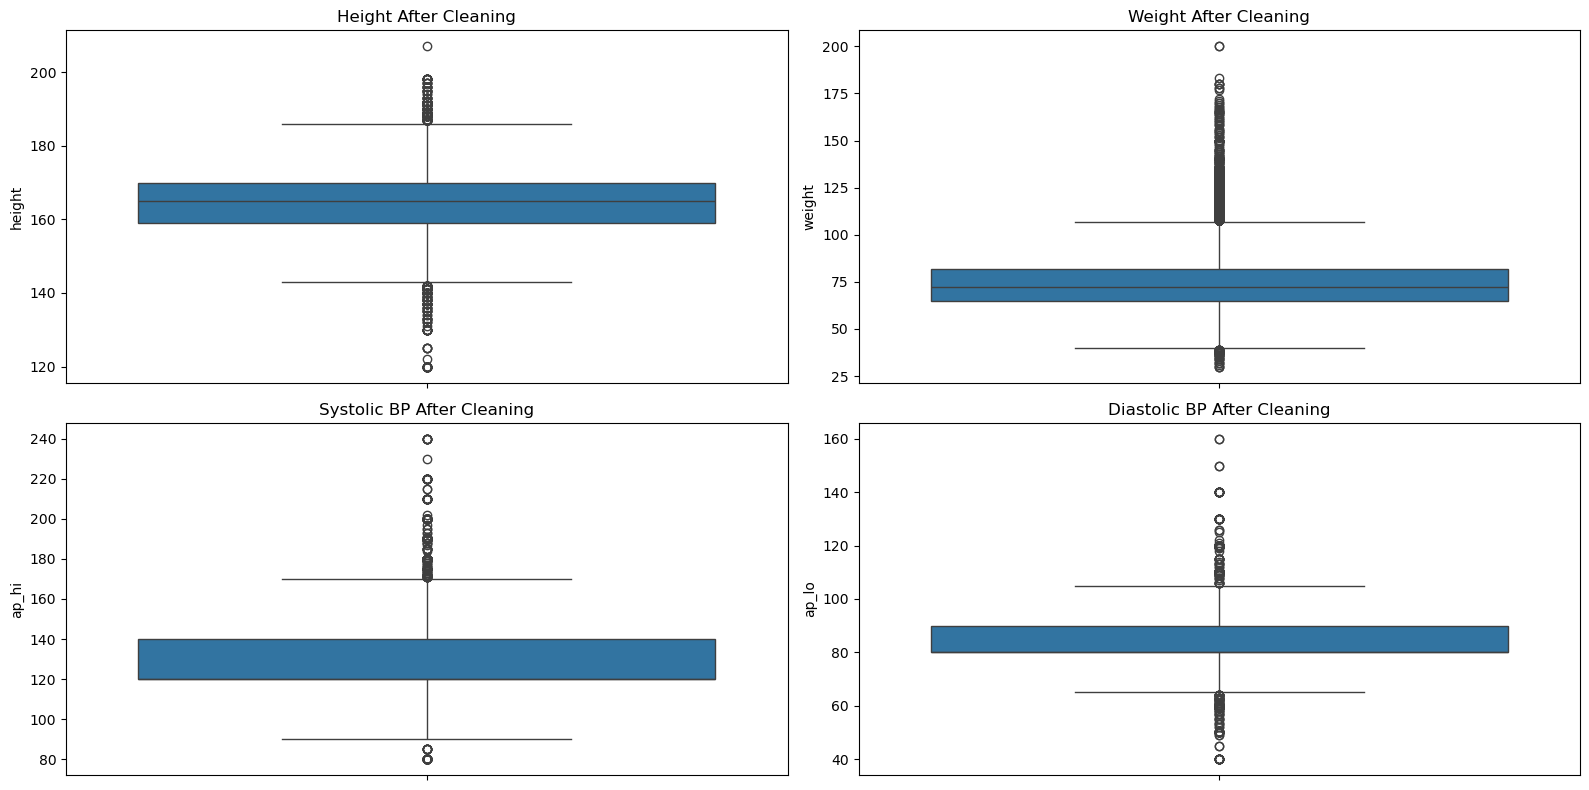

In [44]:
plt.figure(figsize=(16,8))

plt.subplot(2,2,1)
sns.boxplot(df['height'])
plt.title('Height After Cleaning')

plt.subplot(2,2,2)
sns.boxplot(df['weight'])
plt.title('Weight After Cleaning')

plt.subplot(2,2,3)
sns.boxplot(df['ap_hi'])
plt.title('Systolic BP After Cleaning')

plt.subplot(2,2,4)
sns.boxplot(df['ap_lo'])
plt.title('Diastolic BP After Cleaning')

plt.tight_layout()
plt.show()

In [46]:
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 68608 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           68608 non-null  int64  
 1   age          68608 non-null  int64  
 2   gender       68608 non-null  int64  
 3   height       68608 non-null  int64  
 4   weight       68608 non-null  float64
 5   ap_hi        68608 non-null  int64  
 6   ap_lo        68608 non-null  int64  
 7   cholesterol  68608 non-null  int64  
 8   gluc         68608 non-null  int64  
 9   smoke        68608 non-null  int64  
 10  alco         68608 non-null  int64  
 11  active       68608 non-null  int64  
 12  cardio       68608 non-null  int64  
 13  age_years    68608 non-null  int32  
 14  BMI          68608 non-null  float64
dtypes: float64(2), int32(1), int64(12)
memory usage: 8.1 MB
None


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
count,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000,68608.000000
mean,49976.567470,19464.923128,1.348647,164.413786,74.116005,126.676554,81.306276,1.364768,1.225819,0.087964,0.053347,0.803347,0.494724,52.829685,27.457760
std,28846.365495,2467.906471,0.476546,7.912862,14.295634,16.678817,9.426519,0.678964,0.571685,0.283244,0.224725,0.397471,0.499976,6.768554,5.256929
min,0.000000,10798.000000,1.000000,120.000000,30.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,10.726644
25%,25006.750000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115
50%,50018.000000,19702.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.346494
75%,74873.250000,21325.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.117004
max,99999.000000,23713.000000,2.000000,207.000000,200.000000,240.000000,160.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,108.169847


In [48]:
df.to_csv('cleaned_cardiovascular_dataset.csv', index=False)
print('Cleaned dataset saved successfully!')

Cleaned dataset saved successfully!


## **EDA**

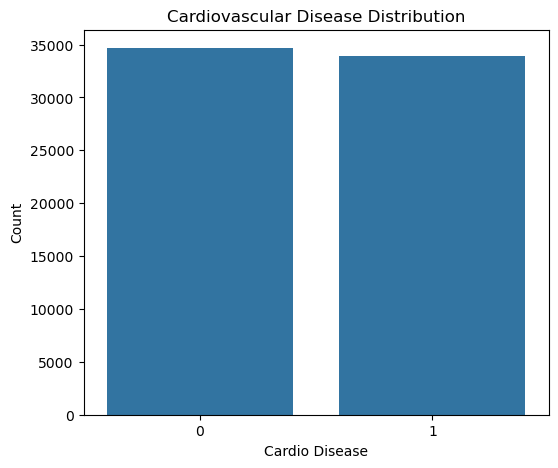

The dataset is relatively balanced between patients with and without cardiovascular disease,
making it suitable for classification tasks.


In [50]:
plt.figure(figsize=(6,5))

sns.countplot(x='cardio', data=df)

plt.title('Cardiovascular Disease Distribution')
plt.xlabel('Cardio Disease')
plt.ylabel('Count')

plt.show()
print("The dataset is relatively balanced between patients with and without cardiovascular disease,") 
print("making it suitable for classification tasks.")

In [52]:
cardio_percent = df['cardio'].value_counts(normalize=True) * 100
print(cardio_percent)

cardio
0    50.527635
1    49.472365
Name: proportion, dtype: float64


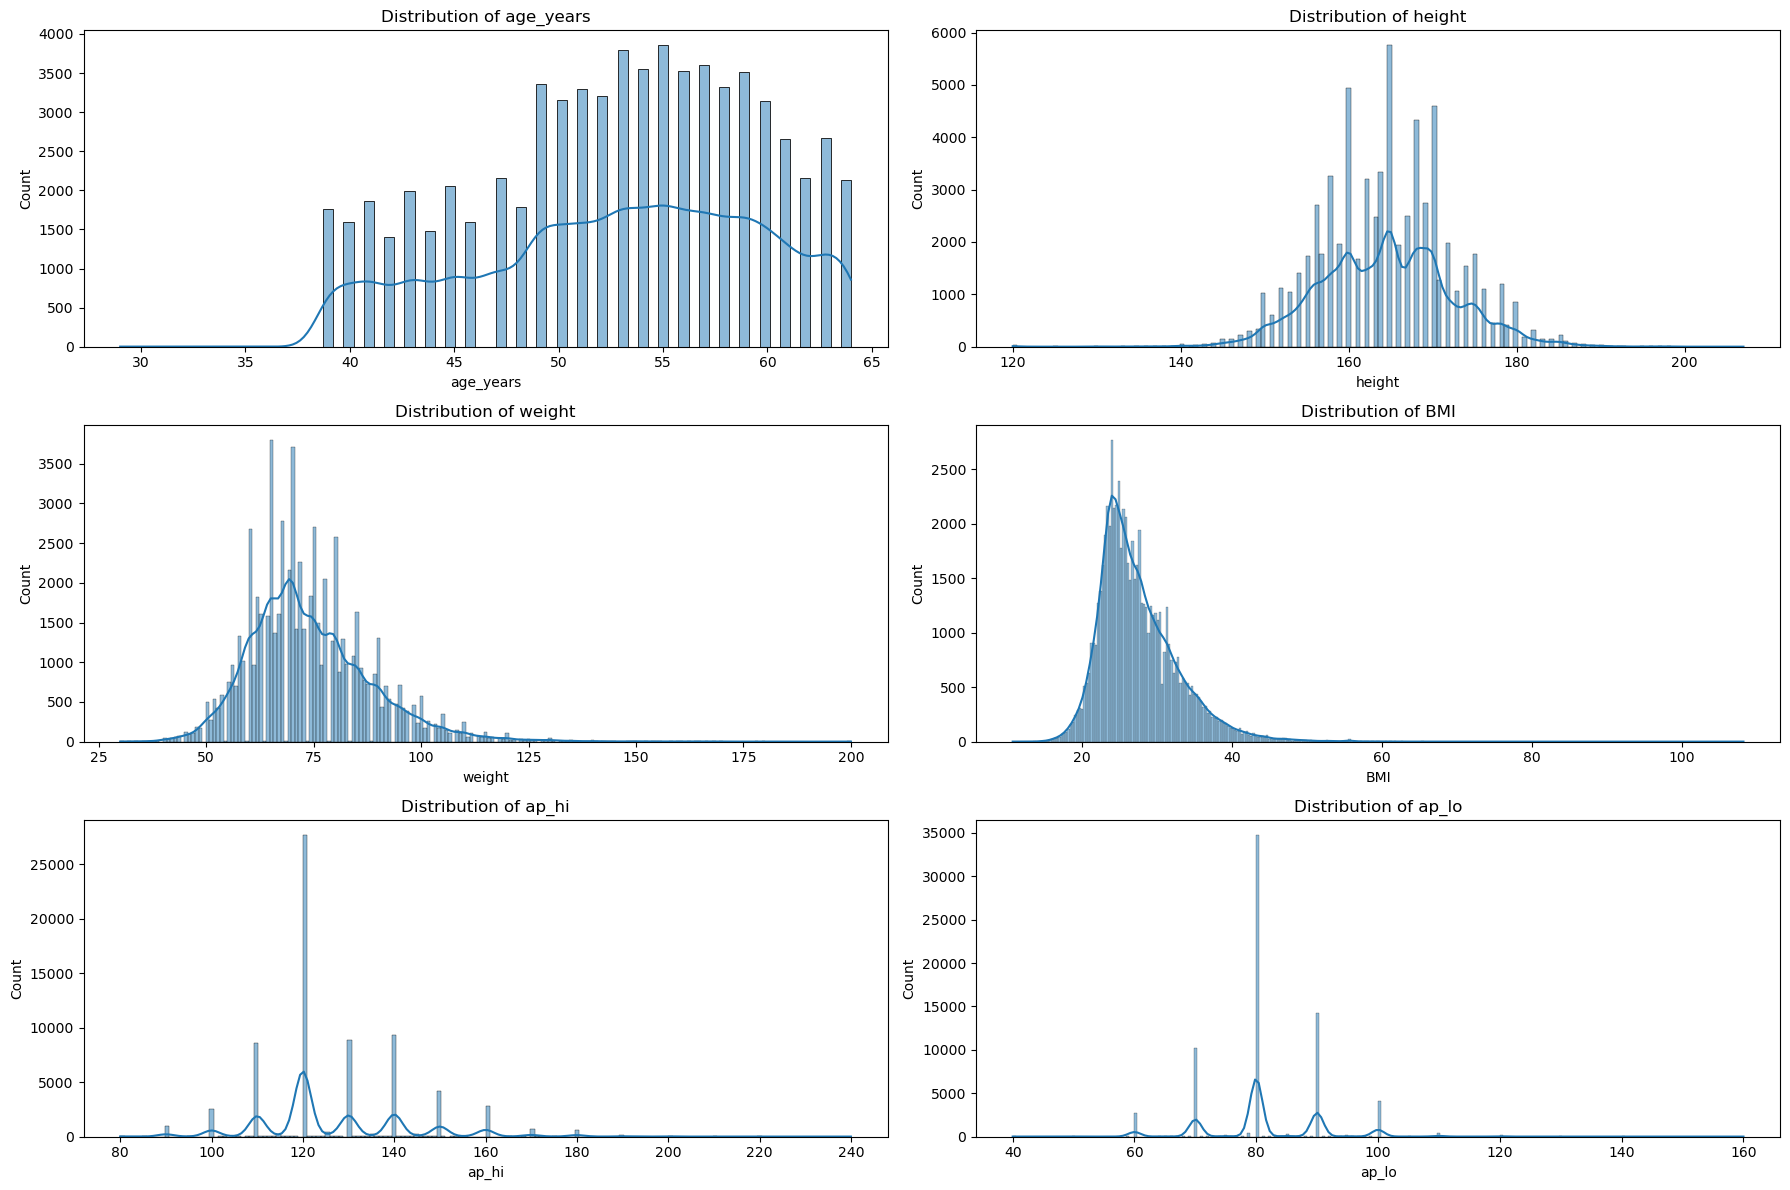

In [54]:
numerical_features = ['age_years', 'height', 'weight', 'BMI', 'ap_hi', 'ap_lo']

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_features):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

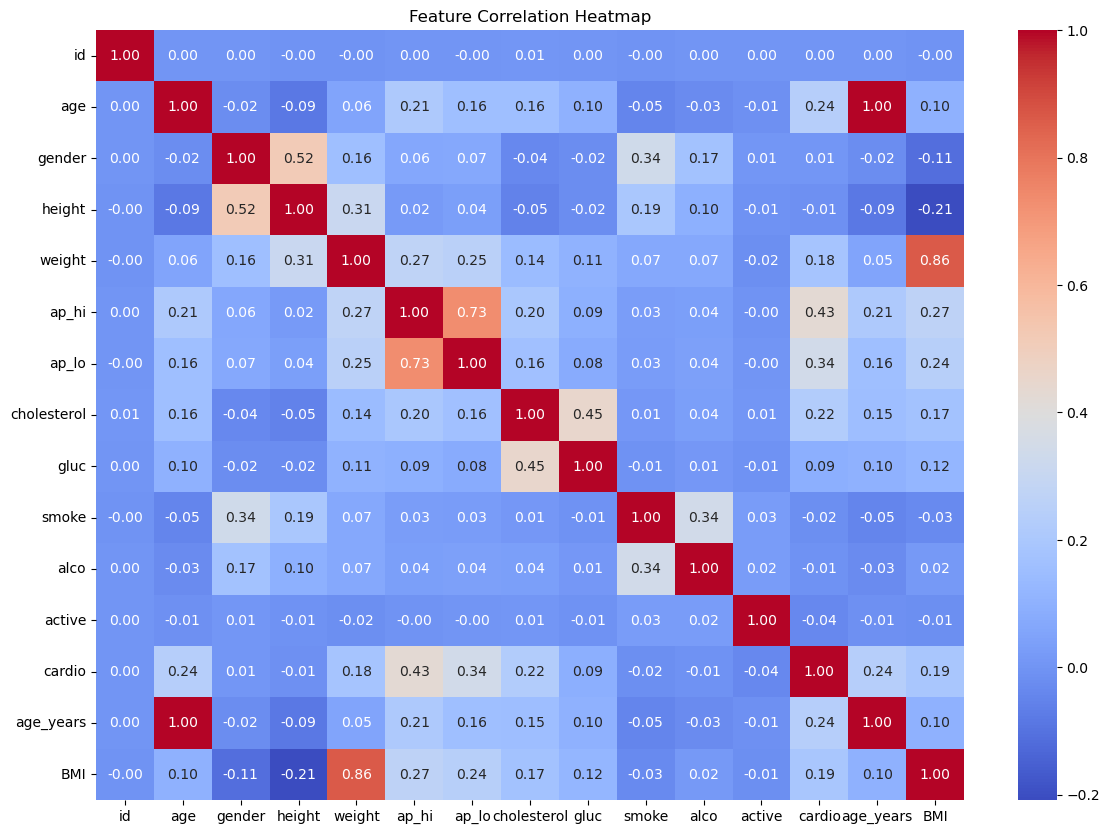

Blood pressure, cholesterol level, and age showed positive correlation with
cardiovascular disease, indicating their importance as predictive features.


In [56]:
plt.figure(figsize=(14,10))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Feature Correlation Heatmap')
plt.show()
print("Blood pressure, cholesterol level, and age showed positive correlation with")
print("cardiovascular disease, indicating their importance as predictive features.")

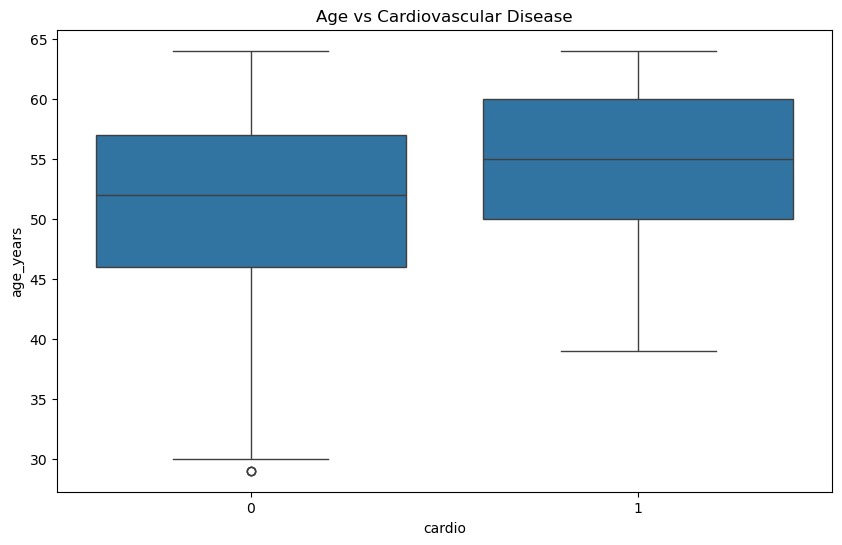

Patients with cardiovascular disease tend to be older.
This creates STRONG medical interpretation.


In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(x='cardio', y='age_years', data=df)

plt.title('Age vs Cardiovascular Disease')

plt.show()

print("Patients with cardiovascular disease tend to be older.")
print("This creates STRONG medical interpretation.")

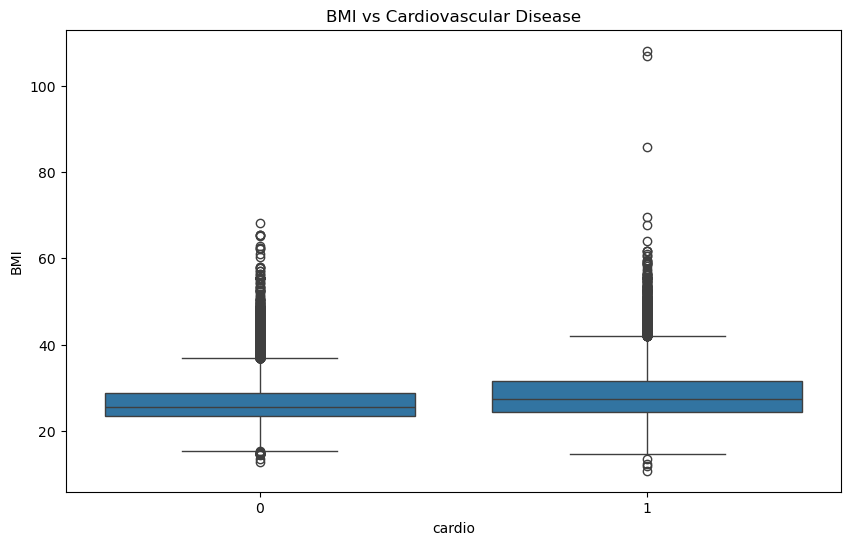

Higher BMI is associated with increased cardiovascular risk.


In [60]:
plt.figure(figsize=(10,6))

sns.boxplot(x='cardio', y='BMI', data=df)

plt.title('BMI vs Cardiovascular Disease')

plt.show()
print("Higher BMI is associated with increased cardiovascular risk.")

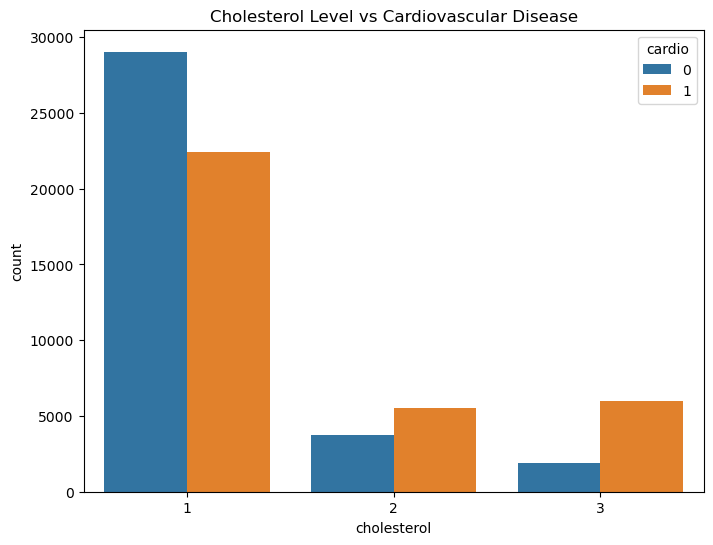

Higher cholesterol levels correspond to higher cardiovascular disease prevalence.


In [62]:
plt.figure(figsize=(8,6))

sns.countplot(x='cholesterol', hue='cardio', data=df)

plt.title('Cholesterol Level vs Cardiovascular Disease')

plt.show()
print("Higher cholesterol levels correspond to higher cardiovascular disease prevalence.")

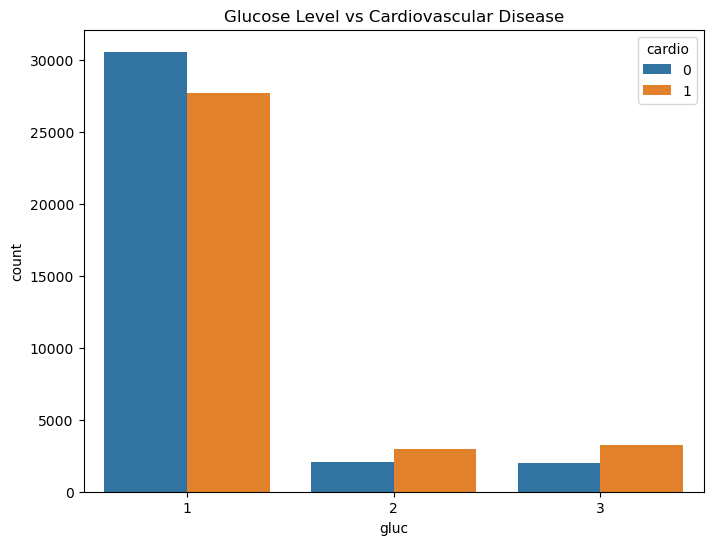

In [64]:
plt.figure(figsize=(8,6))

sns.countplot(x='gluc', hue='cardio', data=df)

plt.title('Glucose Level vs Cardiovascular Disease')

plt.show()

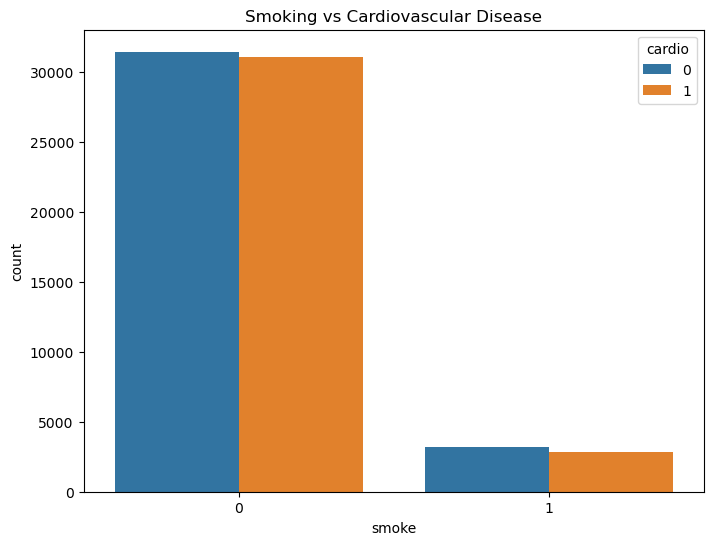

In [66]:
plt.figure(figsize=(8,6))

sns.countplot(x='smoke', hue='cardio', data=df)

plt.title('Smoking vs Cardiovascular Disease')

plt.show()

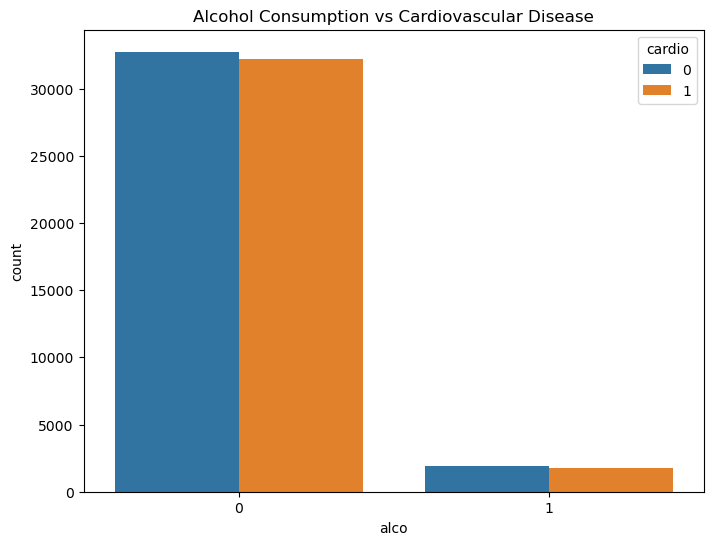

In [68]:
plt.figure(figsize=(8,6))

sns.countplot(x='alco', hue='cardio', data=df)

plt.title('Alcohol Consumption vs Cardiovascular Disease')

plt.show()

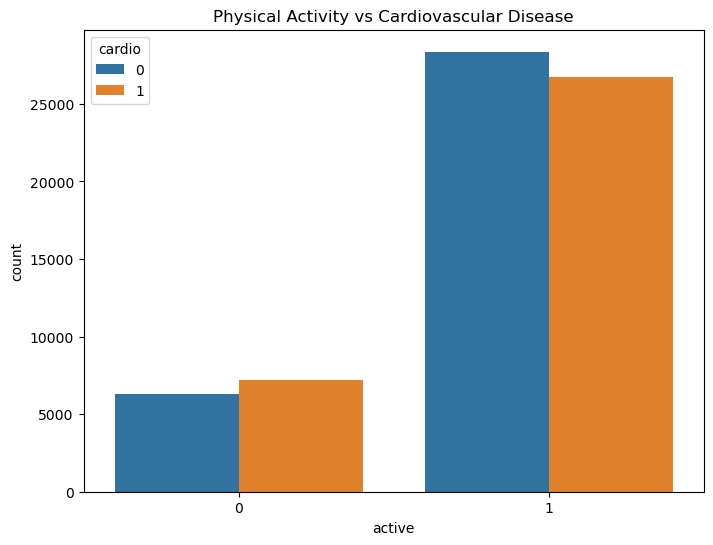

In [70]:
plt.figure(figsize=(8,6))

sns.countplot(x='active', hue='cardio', data=df)

plt.title('Physical Activity vs Cardiovascular Disease')

plt.show()

Physically active individuals have lower disease prevalence.

This creates STRONG real-world discussion.

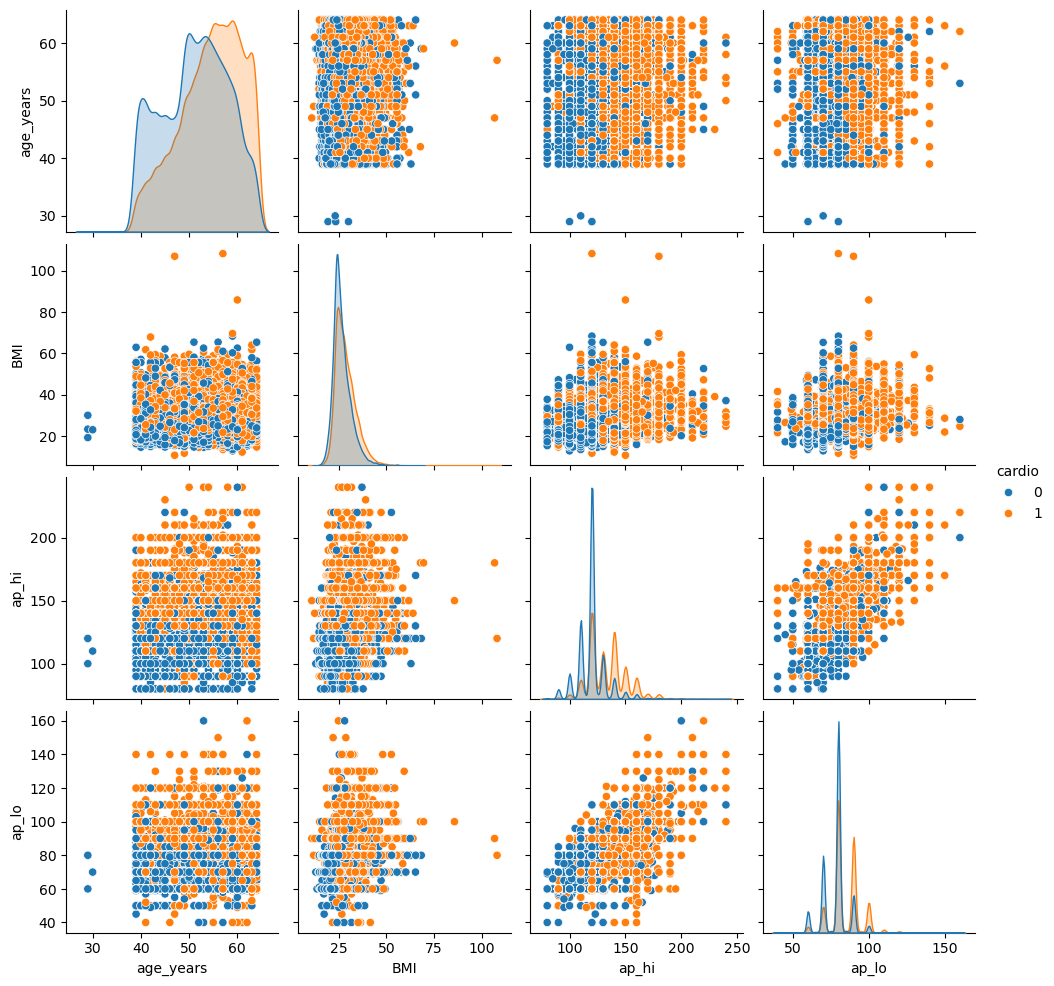

In [72]:
selected_columns = ['age_years', 'BMI', 'ap_hi', 'ap_lo', 'cardio']

sns.pairplot(df[selected_columns], hue='cardio')

plt.show()

EDA KEY FINDINGS:

1. Older individuals show higher cardiovascular disease prevalence.

2. Higher systolic blood pressure strongly relates to cardiovascular disease.

3. Increased BMI correlates with increased disease risk.

4. Cholesterol level is an important predictor.

5. Physical activity appears protective against cardiovascular disease.

6. The dataset is sufficiently balanced for classification modeling.

## **prepperation**

In [74]:
df = df.drop(columns=['id'])

print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years        BMI  
0     0       1       0         50  21.967120  
1     0       1       1         55  34.927679  
2     0       0       1         51  23.507805  
3     0       1       1         48  28.710479  
4     0       0       0         47  23.011177  


In [76]:
X = df.drop('cardio', axis=1)

y = df['cardio']

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)

Feature Shape: (68608, 13)
Target Shape: (68608,)


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (54886, 13)
X_test: (13722, 13)
y_train: (54886,)
y_test: (13722,)


In [80]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print('Scaling completed successfully!')

Scaling completed successfully!


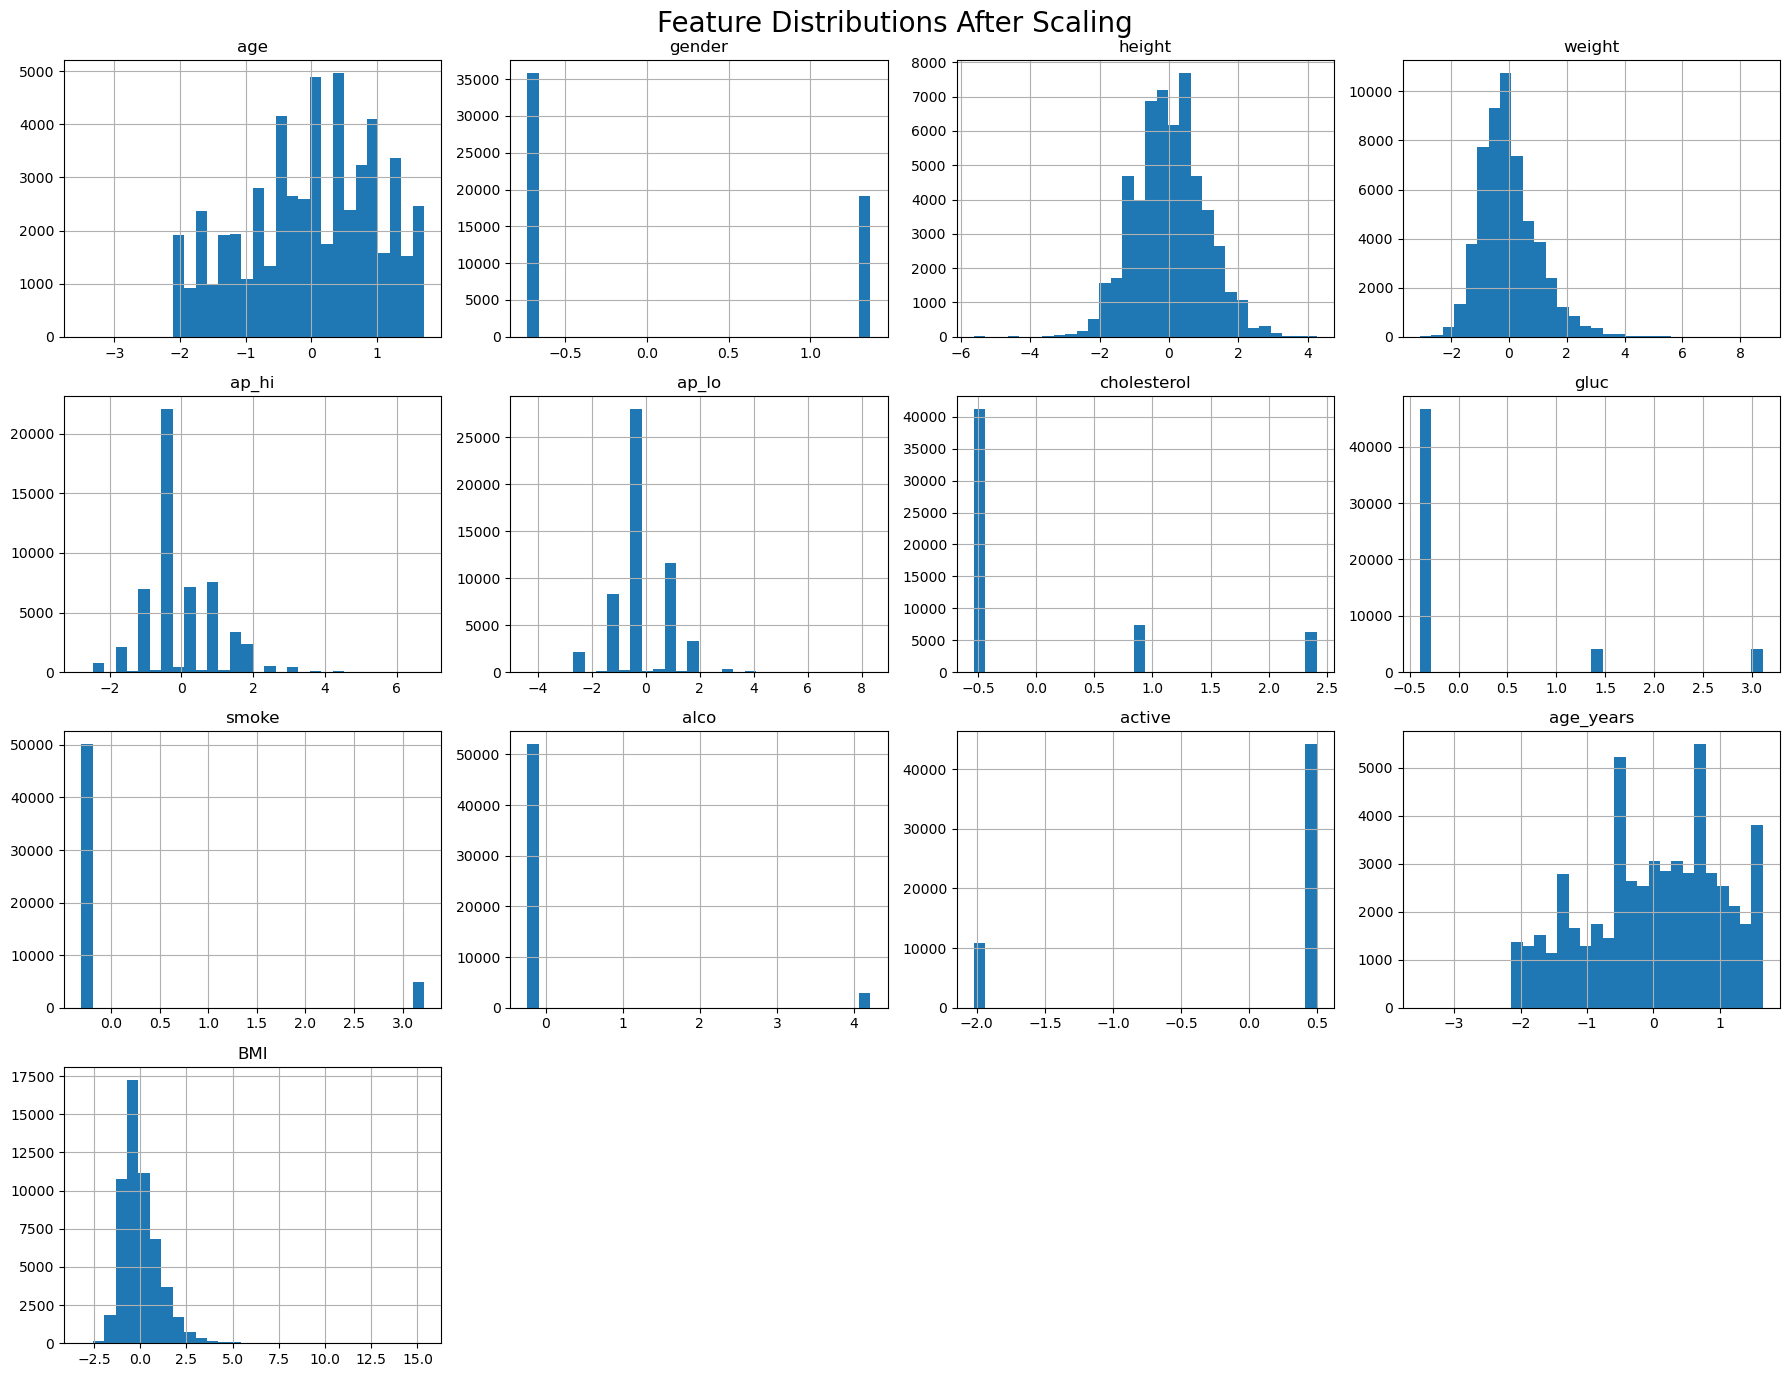

In [82]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

X_train_scaled_df.hist(figsize=(18,14), bins=30)

plt.suptitle('Feature Distributions After Scaling', fontsize=20)

plt.tight_layout()
plt.show()

In [84]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [86]:
rf_preview = RandomForestClassifier(random_state=42)

rf_preview.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_preview.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

        Feature  Importance
0           age    0.200695
4         ap_hi    0.167075
12          BMI    0.151877
3        weight    0.114826
2        height    0.108315
5         ap_lo    0.082367
11    age_years    0.073932
6   cholesterol    0.037560
1        gender    0.016839
7          gluc    0.016447
10       active    0.014102
8         smoke    0.008773
9          alco    0.007191


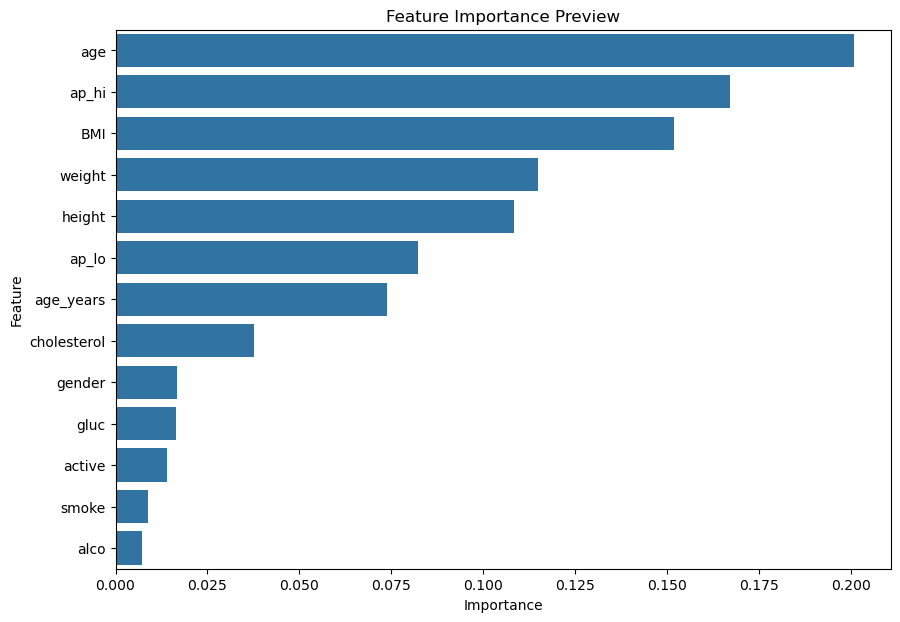

In [88]:
plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance Preview')

plt.show()

## **training models**

In [90]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    
    
    model.fit(X_train, y_train)
    
    
    y_pred = model.predict(X_test)
    
    
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred
    
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Print results
    print(f'===== {model_name} =====')
    print('Accuracy:', round(accuracy,4))
    print('Precision:', round(precision,4))
    print('Recall:', round(recall,4))
    print('F1 Score:', round(f1,4))
    print('ROC AUC:', round(roc_auc,4))
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }

In [92]:
log_model = LogisticRegression(max_iter=1000)

log_results = evaluate_model(
    log_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    'Logistic Regression'
)

===== Logistic Regression =====
Accuracy: 0.7272
Precision: 0.7558
Recall: 0.6625
F1 Score: 0.7061
ROC AUC: 0.7928


In [94]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


dt_results = evaluate_model(
    dt_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'Decision Tree'
)

===== Decision Tree =====
Accuracy: 0.7348
Precision: 0.7629
Recall: 0.6731
F1 Score: 0.7152
ROC AUC: 0.7922


In [96]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model(
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'Random Forest'
)

===== Random Forest =====
Accuracy: 0.7364
Precision: 0.7595
Recall: 0.6838
F1 Score: 0.7196
ROC AUC: 0.8027


In [98]:
knn_model = KNeighborsClassifier(n_neighbors=7)

knn_results = evaluate_model(
    knn_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    'KNN'
)

===== KNN =====
Accuracy: 0.7056
Precision: 0.7087
Recall: 0.6876
F1 Score: 0.698
ROC AUC: 0.7589


In [100]:
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_results = evaluate_model(
    ada_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'AdaBoost'
)

===== AdaBoost =====
Accuracy: 0.7194
Precision: 0.7729
Recall: 0.6131
F1 Score: 0.6838
ROC AUC: 0.7906


In [102]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_results = evaluate_model(
    gb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'Gradient Boosting'
)

===== Gradient Boosting =====
Accuracy: 0.7325
Precision: 0.7541
Recall: 0.6817
F1 Score: 0.7161
ROC AUC: 0.8026


In [104]:
results_df = pd.DataFrame([
    log_results,
    dt_results,
    rf_results,
    knn_results,
    ada_results,
    gb_results,
])

results_df = results_df.sort_values(by='ROC AUC', ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.736409,0.759490,0.683753,0.719634,0.802679
5,Gradient Boosting,0.732546,0.754114,0.681691,0.716076,0.802607
0,Logistic Regression,0.727153,0.755839,0.662542,0.706122,0.792765
1,Decision Tree,0.734805,0.762938,0.673148,0.715236,0.792215
4,AdaBoost,0.719429,0.772888,0.613051,0.683752,0.790632
3,KNN,0.705582,0.708669,0.687583,0.697967,0.758891


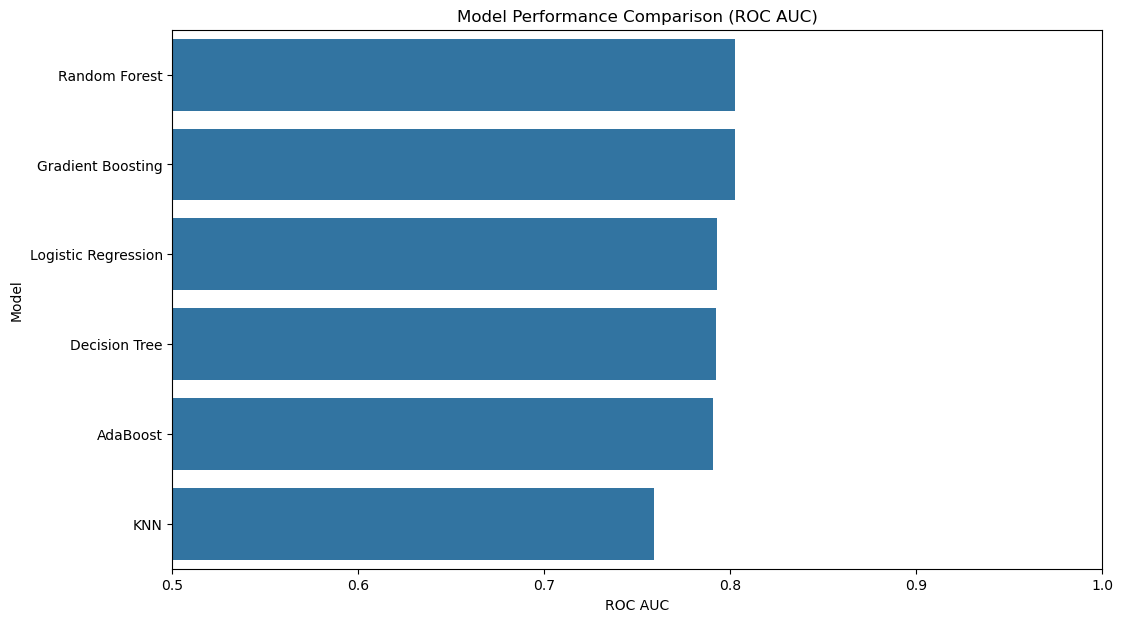

In [106]:
plt.figure(figsize=(12,7))

sns.barplot(
    x='ROC AUC',
    y='Model',
    data=results_df
)

plt.title('Model Performance Comparison (ROC AUC)')

plt.xlim(0.5, 1.0)

plt.show()

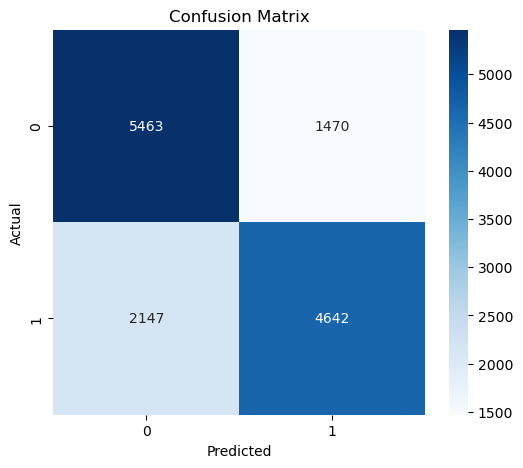

In [108]:
best_model = rf_model

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [110]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_results = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'XGBoost'
)

===== XGBoost =====
Accuracy: 0.7336
Precision: 0.7557
Recall: 0.6821
F1 Score: 0.717
ROC AUC: 0.8025


In [112]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm_results = evaluate_model(
    lgbm_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'LightGBM'
)

[LightGBM] [Info] Number of positive: 27153, number of negative: 27733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 54886, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494716 -> initscore=-0.021136
[LightGBM] [Info] Start training from score -0.021136
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [114]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat_results = evaluate_model(
    cat_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'CatBoost'
)

===== CatBoost =====
Accuracy: 0.736
Precision: 0.7563
Recall: 0.688
F1 Score: 0.7206
ROC AUC: 0.8038


In [116]:
advanced_results_df = pd.DataFrame([
    xgb_results,
    lgbm_results,
    cat_results
])

advanced_results_df = advanced_results_df.sort_values(by='ROC AUC', ascending=False)

advanced_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,CatBoost,0.735971,0.756315,0.688025,0.720555,0.803752
1,LightGBM,0.734660,0.756352,0.684048,0.718385,0.802576
0,XGBoost,0.733639,0.755711,0.682133,0.717040,0.802524


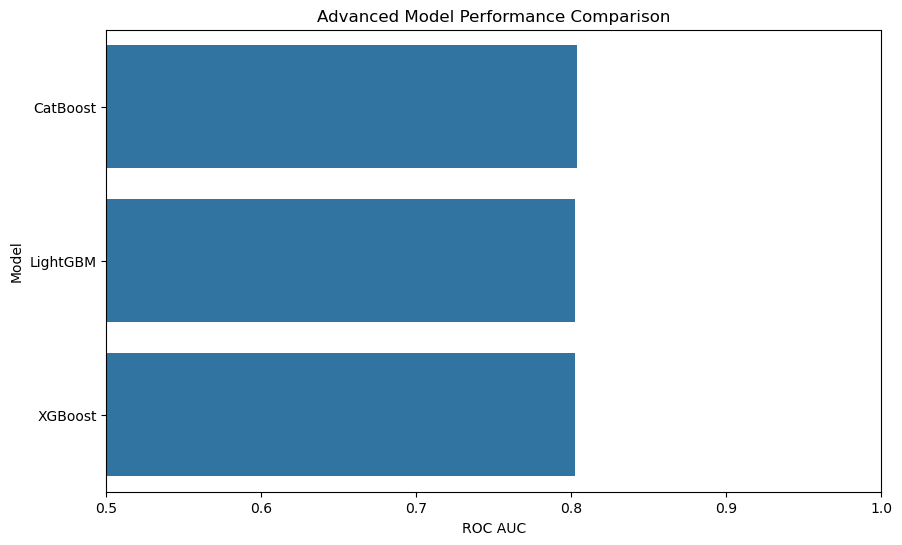

In [118]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='ROC AUC',
    y='Model',
    data=advanced_results_df
)

plt.title('Advanced Model Performance Comparison')

plt.xlim(0.5, 1.0)

plt.show()

In [120]:
all_results_df = pd.DataFrame([
    log_results,
    dt_results,
    rf_results,
    knn_results,
    ada_results,
    gb_results,
    xgb_results,
    lgbm_results,
    cat_results
])

all_results_df = all_results_df.sort_values(by='ROC AUC', ascending=False)

all_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
8,CatBoost,0.735971,0.756315,0.688025,0.720555,0.803752
2,Random Forest,0.736409,0.759490,0.683753,0.719634,0.802679
5,Gradient Boosting,0.732546,0.754114,0.681691,0.716076,0.802607
7,LightGBM,0.734660,0.756352,0.684048,0.718385,0.802576
6,XGBoost,0.733639,0.755711,0.682133,0.717040,0.802524
0,Logistic Regression,0.727153,0.755839,0.662542,0.706122,0.792765
1,Decision Tree,0.734805,0.762938,0.673148,0.715236,0.792215
4,AdaBoost,0.719429,0.772888,0.613051,0.683752,0.790632
3,KNN,0.705582,0.708669,0.687583,0.697967,0.758891


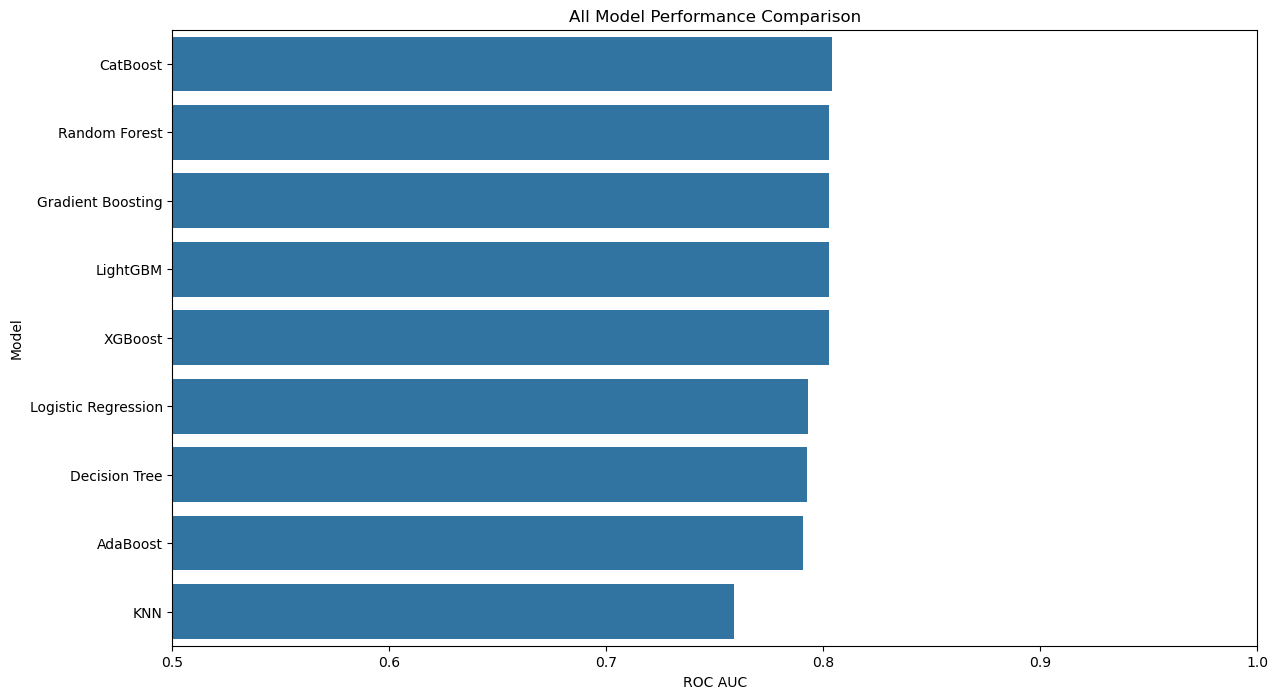

In [122]:
plt.figure(figsize=(14,8))

sns.barplot(
    x='ROC AUC',
    y='Model',
    data=all_results_df
)

plt.title('All Model Performance Comparison')

plt.xlim(0.5, 1.0)

plt.show()

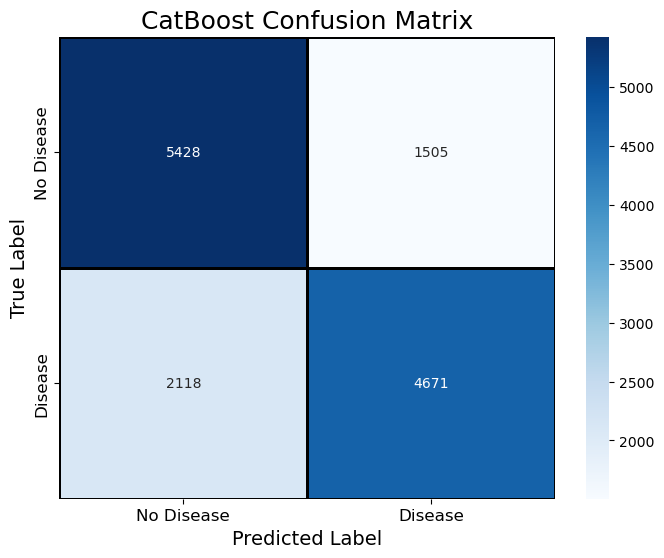

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

y_pred_cat = cat_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title('CatBoost Confusion Matrix', fontsize=18)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

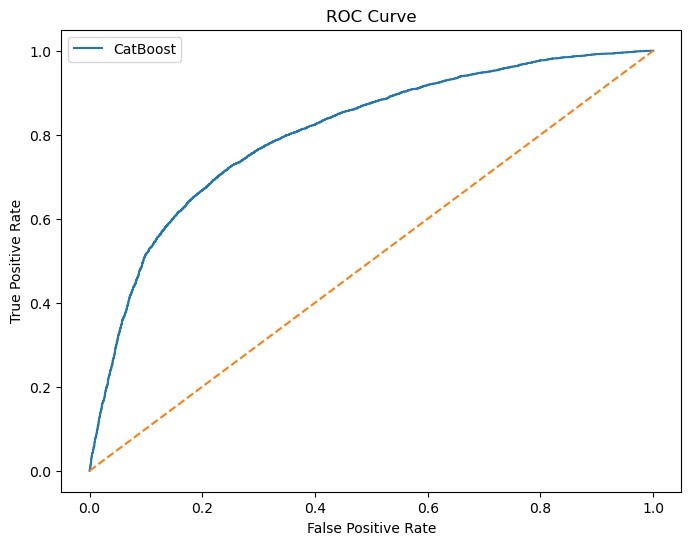

In [124]:
best_model = cat_model

y_prob = best_model.predict_proba(X_test)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='CatBoost')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

## **Hyperparameter tuning**

In [126]:
from sklearn.model_selection import RandomizedSearchCV


cat_params = {
    'depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [100, 200, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}



cat_base = CatBoostClassifier(
    verbose=0,
    random_state=42
)



random_search = RandomizedSearchCV(
    estimator=cat_base,
    param_distributions=cat_params,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)



random_search.fit(X_train, y_train)

print('Best Parameters:')
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 6}


In [127]:
best_cat_model = random_search.best_estimator_



tuned_results = evaluate_model(
    best_cat_model,
    X_train,
    X_test,
    y_train,
    y_test,
    'Tuned CatBoost'
)

===== Tuned CatBoost =====
Accuracy: 0.7359
Precision: 0.7579
Recall: 0.6849
F1 Score: 0.7196
ROC AUC: 0.8041


In [130]:
# Comparison table

comparison_df = pd.DataFrame([
    cat_results,
    tuned_results
])

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,CatBoost,0.735971,0.756315,0.688025,0.720555,0.803752
1,Tuned CatBoost,0.735899,0.757946,0.684932,0.719591,0.804063


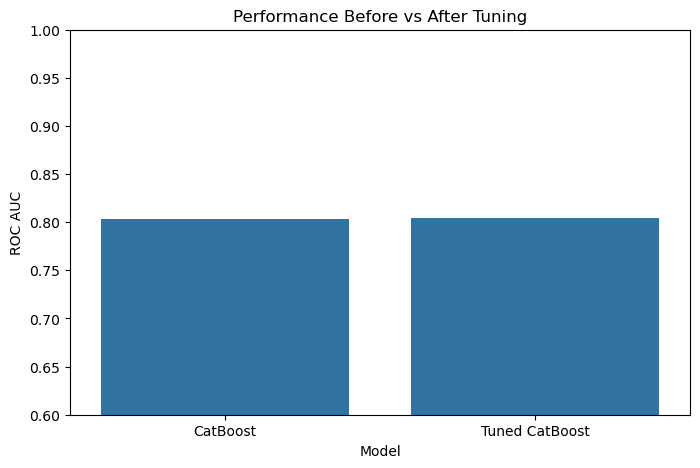

In [132]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC AUC',
    data=comparison_df
)

plt.title('Performance Before vs After Tuning')

plt.ylim(0.6, 1.0)

plt.show()

In [134]:
cv_scores = cross_val_score(
    best_cat_model,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print('Cross Validation Scores:', cv_scores)
print('Mean CV Score:', cv_scores.mean())

Cross Validation Scores: [0.7971504  0.80697587 0.80461321 0.80380214 0.79666928]
Mean CV Score: 0.8018421810710862


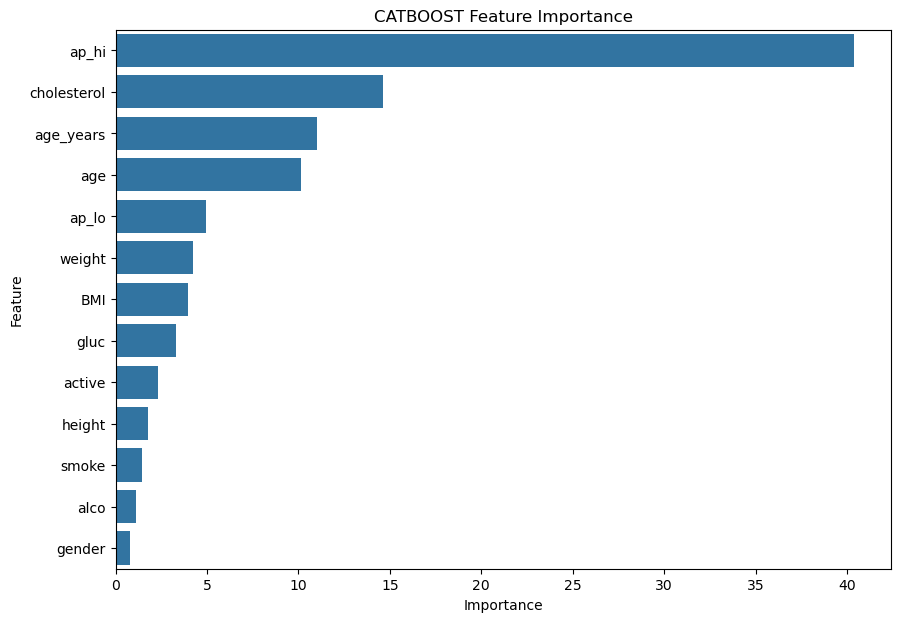

In [136]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot

plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title("CATBOOST Feature Importance")
plt.show()

## **Unseen data**

In [142]:
unseen_df = pd.read_csv("CHD_preprocessed.csv")

print("Dataset Shape:", unseen_df.shape)

unseen_df.head()

Dataset Shape: (4133, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,1,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [144]:
unseen_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4133 entries, 0 to 4132
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4133 non-null   int64  
 1   age              4133 non-null   int64  
 2   education        4133 non-null   int64  
 3   currentSmoker    4133 non-null   int64  
 4   cigsPerDay       4133 non-null   float64
 5   BPMeds           4133 non-null   float64
 6   prevalentStroke  4133 non-null   int64  
 7   prevalentHyp     4133 non-null   int64  
 8   diabetes         4133 non-null   int64  
 9   totChol          4133 non-null   float64
 10  sysBP            4133 non-null   float64
 11  diaBP            4133 non-null   float64
 12  BMI              4133 non-null   float64
 13  heartRate        4133 non-null   float64
 14  glucose          4133 non-null   float64
 15  TenYearCHD       4133 non-null   int64  
dtypes: float64(8), int64(8)
memory usage: 516.8 KB


In [146]:
unseen_df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [148]:
unseen_df = unseen_df.dropna()

In [158]:
X2 = unseen_df.drop("TenYearCHD", axis=1)

y2 = unseen_df["TenYearCHD"]

In [160]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [162]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)

X2_test_scaled = scaler2.transform(X2_test)

In [164]:
from catboost import CatBoostClassifier

cat2 = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    verbose=0,
    random_state=42
)

cat2.fit(X2_train, y2_train)

CatBoostClassifier(depth=5, iterations=300, learning_rate=0.05, random_state=42, verbose=0)

In [166]:
pred2 = cat2.predict(X2_test)

prob2 = cat2.predict_proba(X2_test)[:,1]

In [168]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("="*50)
print("SECONDARY DATASET RESULTS")
print("="*50)

print("Accuracy :", accuracy_score(y2_test, pred2))
print("Precision:", precision_score(y2_test, pred2))
print("Recall   :", recall_score(y2_test, pred2))
print("F1 Score :", f1_score(y2_test, pred2))
print("ROC AUC  :", roc_auc_score(y2_test, prob2))

SECONDARY DATASET RESULTS
Accuracy : 0.8464328899637243
Precision: 0.47058823529411764
Recall   : 0.06349206349206349
F1 Score : 0.11188811188811189
ROC AUC  : 0.7187917487489528


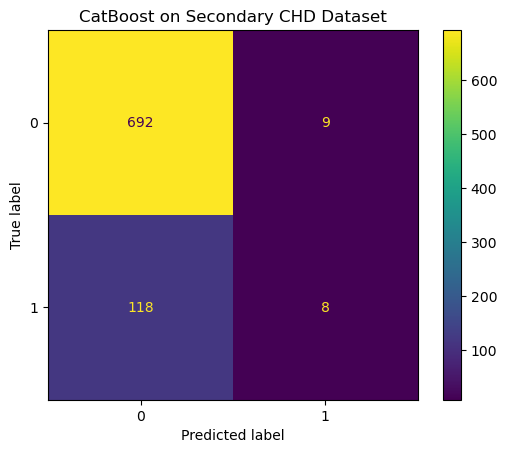

In [170]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    cat2,
    X2_test,
    y2_test
)

plt.title("CatBoost on Secondary CHD Dataset")

plt.show()

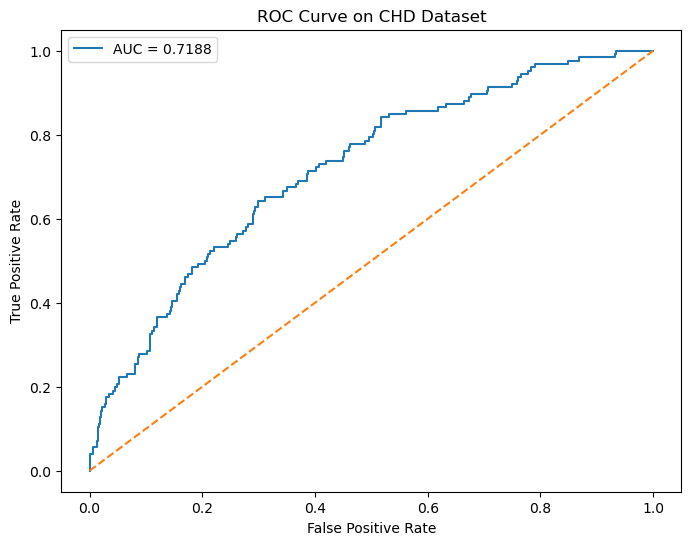

In [172]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(
    y2_test,
    prob2
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve on CHD Dataset")

plt.legend()

plt.show()



### 1. Analysis of Ensemble Learning in Cardiology
**Source:** Mohan, S., Thirumalai, C., & Srivastava, G. (2019). *Effective Heart Disease Prediction Using Hybrid Machine Learning Techniques.*

The researchers analyzed the impact of feature engineering on the accuracy of cardiovascular risk assessment. The study concluded that ensemble-based models, specifically **Random Forest**, provide superior performance (up to 88% accuracy) by identifying non-linear patterns in clinical data. This research supports our approach to data preprocessing, including outlier removal and the derivation of the Body Mass Index (BMI) as a key predictive feature.

### 2. Evaluation of Gradient Boosting Algorithms
**Source:** Shorewala, V. (2021). *Performance Analysis of Machine Learning Algorithms for Cardiovascular Disease Prediction.*

This paper provides a comparative study of modern boosting frameworks, such as XGBoost, LightGBM, and CatBoost. The author demonstrated that **CatBoost** outperforms traditional algorithms when dealing with categorical medical variables (e.g., cholesterol and glucose levels). The study highlights that CatBoost's internal handling of categorical data leads to higher ROC-AUC scores. These findings align with our experimental results, where CatBoost was identified as the optimal model for the final prediction task.